# W-State Routing Comparison: IQM Qubit Selector vs Beam-Search Chain Routing

This notebook runs the **same W-state preparation circuit** through two routing strategies and compares:

| | **IQM Qubit Selector** | **Beam-Search Chain Routing** |
|---|---|---|
| Qubit selection | `CostEvaluator` (GATE_COST_CZ + QNDNESS) | Custom beam search (CZ × readout × T1 × T2) |
| Transpilation | Qiskit `optimization_level=3` | `routing_method='none'` (chain guarantee) |
| SWAP overhead | Possible SWAPs inserted by Qiskit | **Zero SWAPs** by construction |
| Key insight | Best *subset* of qubits for arbitrary topology | Best *path* of qubits → linear interaction graph |

**Why this matters:** The F-gate W-state circuit has a strictly linear interaction graph (each 2-qubit gate is between consecutive logical qubits). Mapping it onto a hardware *path* of the same length eliminates all SWAP overhead — at the cost of a more constrained qubit search.

In [18]:
N_QUBITS   = 10    # W-state size (keep ≤ 20; chain routing needs a hardware path of this length)
SHOTS      = 500   # shots per circuit
BEAM_WIDTH = 100   # beam search width for chain routing

## 1. Connect to IQM Resonance

In [19]:
import os
from pathlib import Path
from iqm.qiskit_iqm import IQMProvider

secret_path = Path.cwd() / ".secrets" / "iqm_api_key"
api_token = secret_path.read_text().strip() if secret_path.exists() \
            else input("IQM Resonance API token: ").strip()
os.environ["IQM_TOKEN"] = api_token

provider = IQMProvider("https://resonance.meetiqm.com", quantum_computer="emerald")
backend  = provider.get_backend()
print(f"Connected: {backend.name}  ({backend.num_qubits} qubits)")

Connected: IQMBackend  (54 qubits)


## 2. Load calibration data

In [20]:
import math
import numpy as np
from iqm.qubit_selector.qubit_selector import CalibrationDataManager

cal = CalibrationDataManager().get_calibration_fidelities(backend)

def _parse_pair(fid_dict):
    out = {}
    for k, v in fid_dict.items():
        try:
            names = eval(k)
            idxs  = tuple(backend.qubit_name_to_index(n) for n in names)
            out[frozenset(idxs)] = float(v)
        except Exception:
            pass
    return out

def _parse_qubit(raw):
    out = {}
    for name, v in raw.items():
        try:
            out[backend.qubit_name_to_index(name)] = float(v)
        except Exception:
            pass
    return out

cz_fid  = _parse_pair(cal.get("CZ", {}))
ro_fid  = _parse_qubit(cal.get("readout", {}))
t1_us   = _parse_qubit(cal.get("t1", {}))
t2_us   = _parse_qubit(cal.get("t2", {}))

# Estimate W-state circuit duration
cz_durations = []
if "cz" in backend.target:
    for qargs, props in backend.target["cz"].items():
        if props and props.duration:
            cz_durations.append(props.duration)
mean_cz_ns = np.mean(cz_durations) * 1e9 if cz_durations else 80.0
circuit_ns  = 3 * (N_QUBITS - 1) * mean_cz_ns

def t1_survival(phys, wait_ns, default_t1_us=200.0):
    return float(np.exp(-wait_ns / (t1_us.get(phys, default_t1_us) * 1e3)))

def t2_survival(phys, wait_ns, default_t2_us=100.0):
    return float(np.exp(-wait_ns / (t2_us.get(phys, default_t2_us) * 1e3)))

print(f"CZ fidelity edges:  {len(cz_fid)}")
print(f"Readout fid qubits: {len(ro_fid)}")
print(f"Mean CZ duration:   {mean_cz_ns:.1f} ns")
print(f"W{N_QUBITS} circuit duration estimate: {circuit_ns:.0f} ns  ({circuit_ns/1000:.2f} µs)")

CZ fidelity edges:  81
Readout fid qubits: 54
Mean CZ duration:   80.0 ns
W10 circuit duration estimate: 2160 ns  (2.16 µs)


## 3. Build the W-state circuit (F-gate / Diker method)

Both approaches use **identical circuits** — the only difference is the qubit mapping.

The F-gate interaction graph is strictly **linear**: gate $k$ connects logical qubits $k-1$ and $k$.  
This is the key property our chain routing exploits.

In [21]:
from qiskit import QuantumCircuit
import numpy as np

def _f_gate(qc, ctrl, tgt, theta):
    qc.ry(-theta, tgt)
    qc.cz(ctrl, tgt)
    qc.ry(theta, tgt)

def build_w_state_n(n):
    qc = QuantumCircuit(n, name=f"W{n}")
    qc.x(0)
    for k in range(1, n):
        theta = np.arccos(np.sqrt(1.0 / (n - k + 1)))
        _f_gate(qc, k - 1, k, theta)
    for k in range(n - 1):
        qc.cx(k + 1, k)
    return qc

qc_w = build_w_state_n(N_QUBITS)
print(f"W{N_QUBITS} circuit: depth={qc_w.depth()}, ops={dict(qc_w.count_ops())}")
print(f"Two-qubit gate pairs (logical): {[(k-1,k) for k in range(1,N_QUBITS)] + [(k+1,k) for k in range(N_QUBITS-1)]}")

W10 circuit: depth=20, ops={'ry': 18, 'cz': 9, 'cx': 9, 'x': 1}
Two-qubit gate pairs (logical): [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (1, 0), (2, 1), (3, 2), (4, 3), (5, 4), (6, 5), (7, 6), (8, 7), (9, 8)]


## 4. Approach A — IQM Qubit Selector

The IQM Qubit Selector evaluates qubit *subsets* using calibration data and returns the lowest-cost layout.  
Qiskit then routes the circuit onto that layout with `optimization_level=3` — it may insert SWAP gates.

In [22]:
from iqm.qubit_selector.qubit_selector import (
    CostEvaluator, CostFunction, ReadoutMode,
)
from qiskit import transpile

qc_w_measured = build_w_state_n(N_QUBITS)
qc_w_measured.measure_all()

layouts_iqm, costs_iqm = CostEvaluator(
    backend=backend,
    quantum_circuit=qc_w_measured,
    cost_function=CostFunction.GATE_COST_CZ,
    readoutmode=ReadoutMode.QNDNESS,
    num_trials=2000,
).get_top_layouts(num_layouts=10)

iqm_layout = list(layouts_iqm[0])
iqm_names  = [backend.index_to_qubit_name(q) for q in iqm_layout]
iqm_cost   = costs_iqm[0]

print(f"IQM Selector — top 5 layouts (cost = lower is better):")
for rank, (lay, cost) in enumerate(zip(layouts_iqm[:5], costs_iqm[:5]), 1):
    names = [backend.index_to_qubit_name(q) for q in lay]
    print(f"  Rank {rank}: {names}  cost={cost:.4f}")
print(f"\n✓ Selected: {iqm_names}  (cost={iqm_cost:.4f})")

# Build Z and X circuits, transpile with full Qiskit routing
qc_z_iqm = build_w_state_n(N_QUBITS); qc_z_iqm.measure_all()
qc_x_iqm = build_w_state_n(N_QUBITS)
qc_x_iqm.h(range(N_QUBITS)); qc_x_iqm.measure_all()

qc_z_iqm_t = transpile(qc_z_iqm, backend=backend, initial_layout=iqm_layout, optimization_level=3)
qc_x_iqm_t = transpile(qc_x_iqm, backend=backend, initial_layout=iqm_layout, optimization_level=3)

iqm_z_depth = qc_z_iqm_t.depth()
iqm_x_depth = qc_x_iqm_t.depth()
iqm_z_swaps = qc_z_iqm_t.count_ops().get("swap", 0)
iqm_x_swaps = qc_x_iqm_t.count_ops().get("swap", 0)

print(f"\nIQM Selector — transpiled circuit stats:")
print(f"  Z-basis: depth={iqm_z_depth}, SWAPs={iqm_z_swaps}")
print(f"  X-basis: depth={iqm_x_depth}, SWAPs={iqm_x_swaps}")

[05-09 18:20:01;I] Number of layouts to evaluate: 842
[05-09 18:20:24;I] Cost evaluation has begun using cost function "gate_cost_cz".
IQM Selector — top 5 layouts (cost = lower is better):
  Rank 1: ['QB1', 'QB34', 'QB33', 'QB5', 'QB6', 'QB10', 'QB11', 'QB12', 'QB18', 'QB26']  cost=0.2333
  Rank 2: ['QB5', 'QB6', 'QB7', 'QB37', 'QB11', 'QB13', 'QB14', 'QB22', 'QB29', 'QB30']  cost=0.2334
  Rank 3: ['QB1', 'QB5', 'QB6', 'QB7', 'QB37', 'QB13', 'QB14', 'QB22', 'QB29', 'QB30']  cost=0.2358
  Rank 4: ['QB1', 'QB34', 'QB5', 'QB6', 'QB10', 'QB11', 'QB12', 'QB42', 'QB18', 'QB26']  cost=0.2399
  Rank 5: ['QB1', 'QB33', 'QB5', 'QB6', 'QB10', 'QB11', 'QB12', 'QB18', 'QB25', 'QB26']  cost=0.2415

✓ Selected: ['QB1', 'QB34', 'QB33', 'QB5', 'QB6', 'QB10', 'QB11', 'QB12', 'QB18', 'QB26']  (cost=0.2333)

IQM Selector — transpiled circuit stats:
  Z-basis: depth=85, SWAPs=0
  X-basis: depth=97, SWAPs=0


## 5. Approach B — Beam-Search Chain Routing

Because the W-state circuit's interaction graph is linear, we can search for a hardware **path** of length N.  
Mapping the circuit onto this path allows transpilation with `routing_method='none'` — **zero SWAPs guaranteed**.

Score each path: $\sum_i \log(\text{CZ}_i) + \log(\text{RO}_i) + \log(e^{-t_i/T_1}) + \log(e^{-t_i/T_2})$

In [23]:
all_edges = list(backend.coupling_map.get_edges())
adj = {}
for u, v in all_edges:
    adj.setdefault(u, set()).add(v)
    adj.setdefault(v, set()).add(u)

def beam_search_chain(n, adj, cz_fid, ro_fid, t1_fn, t2_fn,
                      gate_ns, beam_width,
                      default_cz=0.90, default_ro=0.95):
    def ls(x):
        return math.log(max(x, 1e-12))

    beam = [(ls(ro_fid.get(q, default_ro))
             + ls(t1_fn(q, (n-1)*3*gate_ns))
             + ls(t2_fn(q, (n-1)*3*gate_ns)),
             [q])
            for q in adj]
    beam.sort(reverse=True)
    beam = beam[:beam_width]

    for step in range(n - 1):
        pos     = step + 1
        wait_ns = (n - 1 - pos) * 3 * gate_ns
        candidates = []
        for log_score, path in beam:
            last = path[-1]; used = set(path)
            for nbr in adj[last]:
                if nbr in used:
                    continue
                new_log = (log_score
                           + ls(cz_fid.get(frozenset((last, nbr)), default_cz))
                           + ls(ro_fid.get(nbr, default_ro))
                           + ls(t1_fn(nbr, wait_ns))
                           + ls(t2_fn(nbr, wait_ns)))
                candidates.append((new_log, path + [nbr]))
        if not candidates:
            break
        candidates.sort(reverse=True)
        beam = candidates[:beam_width]

    complete = [(s, p) for s, p in beam if len(p) == n]
    if not complete:
        raise RuntimeError(f"No hardware path of length {n} found — reduce N_QUBITS or increase BEAM_WIDTH")
    best_log, best_path = complete[0]
    return best_path, math.exp(best_log)

chain_layout, chain_score = beam_search_chain(
    N_QUBITS, adj, cz_fid, ro_fid,
    t1_survival, t2_survival,
    mean_cz_ns, BEAM_WIDTH,
)
chain_names = [backend.index_to_qubit_name(q) for q in chain_layout]

print(f"Chain routing — best path (combined score={chain_score:.2e}):")
print(f"  {chain_names}")
print()
print(f"{'Pos':>3}  {'QB':6}  {'Readout':>8}  {'CZ→next':>8}  {'T1(µs)':>8}  {'T2(µs)':>8}")
print("-" * 55)
for i, phys in enumerate(chain_layout):
    cz_next = cz_fid.get(frozenset((phys, chain_layout[i+1])), float("nan")) if i < N_QUBITS-1 else float("nan")
    cz_str  = f"{cz_next:.4f}" if not math.isnan(cz_next) else "  —   "
    print(f"{i:>3}  {chain_names[i]:6}  "
          f"{ro_fid.get(phys, float('nan')):>8.4f}  {cz_str:>8}  "
          f"{t1_us.get(phys, float('nan')):>8.1f}  {t2_us.get(phys, float('nan')):>8.1f}")

# Transpile with no routing — valid only because chain_layout is a hardware path
qc_z_chain = build_w_state_n(N_QUBITS); qc_z_chain.measure_all()
qc_x_chain = build_w_state_n(N_QUBITS)
qc_x_chain.h(range(N_QUBITS)); qc_x_chain.measure_all()

qc_z_chain_t = transpile(qc_z_chain, backend=backend, initial_layout=chain_layout,
                         routing_method="none", optimization_level=1)
qc_x_chain_t = transpile(qc_x_chain, backend=backend, initial_layout=chain_layout,
                         routing_method="none", optimization_level=1)

chain_z_depth = qc_z_chain_t.depth()
chain_x_depth = qc_x_chain_t.depth()
chain_z_swaps = qc_z_chain_t.count_ops().get("swap", 0)
chain_x_swaps = qc_x_chain_t.count_ops().get("swap", 0)

assert chain_z_swaps == 0 and chain_x_swaps == 0, "Unexpected SWAPs in chain routing!"
print(f"\nChain routing — transpiled circuit stats:")
print(f"  Z-basis: depth={chain_z_depth}, SWAPs={chain_z_swaps}")
print(f"  X-basis: depth={chain_x_depth}, SWAPs={chain_x_swaps}")

Chain routing — best path (combined score=5.28e-01):
  ['QB12', 'QB11', 'QB5', 'QB1', 'QB2', 'QB6', 'QB7', 'QB13', 'QB14', 'QB22']

Pos  QB       Readout   CZ→next    T1(µs)    T2(µs)
-------------------------------------------------------
  0  QB12      0.9891    0.9987      58.6      49.5
  1  QB11      0.9922    0.9938      51.8      43.3
  2  QB5       0.9838    0.9918      46.6      45.2
  3  QB1       0.9912    0.9973      51.8      39.4
  4  QB2       0.9917    0.9930      43.8      35.4
  5  QB6       0.9936    0.9919      55.3      33.8
  6  QB7       0.9857    0.9971      48.0      51.1
  7  QB13      0.9893    0.9900      58.8      34.5
  8  QB14      0.9916    0.9824      38.2      36.4
  9  QB22      0.9880      —         48.0      34.5

Chain routing — transpiled circuit stats:
  Z-basis: depth=23, SWAPs=0
  X-basis: depth=23, SWAPs=0


## 6. Pre-run comparison: depth and SWAPs

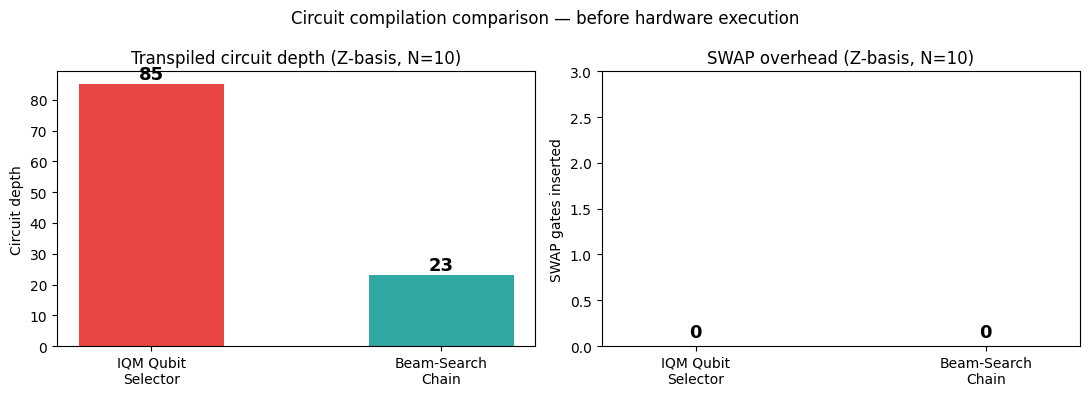


Summary:
  IQM Selector  — qubits: ['QB1', 'QB34', 'QB33', 'QB5', 'QB6', 'QB10', 'QB11', 'QB12', 'QB18', 'QB26']
  Chain routing — qubits: ['QB12', 'QB11', 'QB5', 'QB1', 'QB2', 'QB6', 'QB7', 'QB13', 'QB14', 'QB22']

Metric                            IQM Selector   Chain Routing
--------------------------------------------------------------
Qubits selected                ['QB1', 'QB34', 'QB33', 'QB5', 'QB6', 'QB10', 'QB11', 'QB12', 'QB18', 'QB26'] ['QB12', 'QB11', 'QB5', 'QB1', 'QB2', 'QB6', 'QB7', 'QB13', 'QB14', 'QB22']
Z-basis depth                               85              23
Z-basis SWAPs                                0               0
X-basis depth                               97              23
X-basis SWAPs                                0               0


In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

approaches = ["IQM Qubit\nSelector", "Beam-Search\nChain"]
colors = ["#e84545", "#32a8a4"]

# Depth comparison (Z-basis)
depths = [iqm_z_depth, chain_z_depth]
bars = axes[0].bar(approaches, depths, color=colors, width=0.5)
axes[0].set_ylabel("Circuit depth")
axes[0].set_title(f"Transpiled circuit depth (Z-basis, N={N_QUBITS})")
for bar, val in zip(bars, depths):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha="center", va="bottom", fontsize=13, fontweight="bold")

# SWAP comparison
swaps = [iqm_z_swaps, chain_z_swaps]
bars2 = axes[1].bar(approaches, swaps, color=colors, width=0.5)
axes[1].set_ylabel("SWAP gates inserted")
axes[1].set_title(f"SWAP overhead (Z-basis, N={N_QUBITS})")
axes[1].set_ylim(0, max(swaps) + 2 if max(swaps) > 0 else 3)
for bar, val in zip(bars2, swaps):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(val), ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.suptitle("Circuit compilation comparison — before hardware execution", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  IQM Selector  — qubits: {iqm_names}")
print(f"  Chain routing — qubits: {chain_names}")
print(f"")
print(f"{'Metric':<30} {'IQM Selector':>15} {'Chain Routing':>15}")
print("-" * 62)
print(f"{'Qubits selected':<30} {str(iqm_names):>15} {str(chain_names):>15}")
print(f"{'Z-basis depth':<30} {iqm_z_depth:>15} {chain_z_depth:>15}")
print(f"{'Z-basis SWAPs':<30} {iqm_z_swaps:>15} {chain_z_swaps:>15}")
print(f"{'X-basis depth':<30} {iqm_x_depth:>15} {chain_x_depth:>15}")
print(f"{'X-basis SWAPs':<30} {iqm_x_swaps:>15} {chain_x_swaps:>15}")

## 7. Hardware topology: both routing strategies visualised

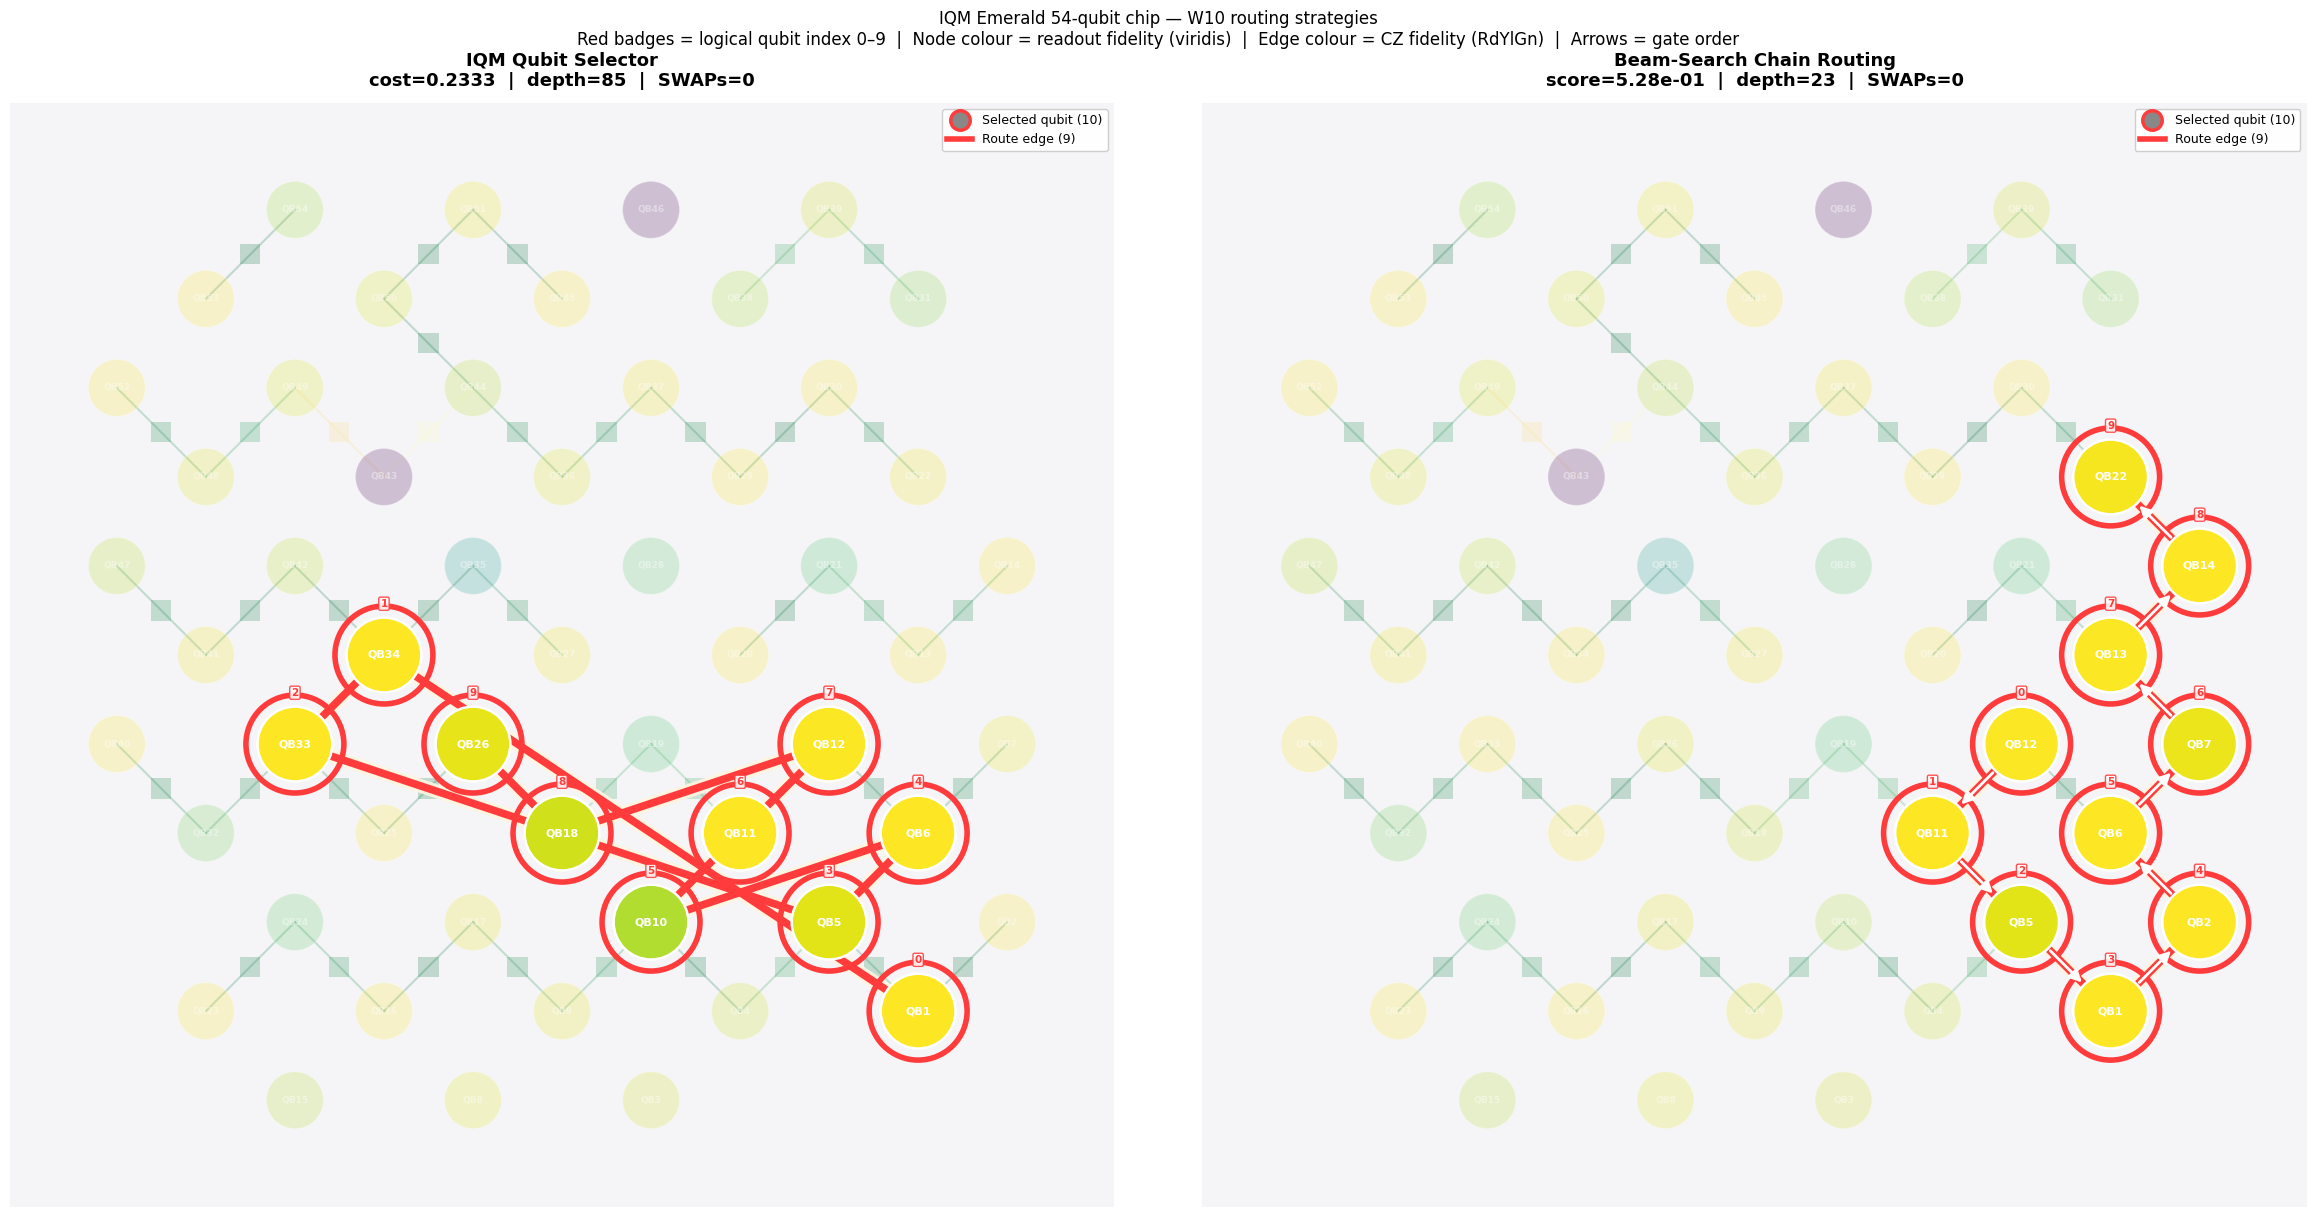

In [25]:
import sys, importlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Hot-reload the viz module so edits to iqm_topology_viz.py take effect without restarting
if "iqm_topology_viz" in sys.modules:
    importlib.reload(sys.modules["iqm_topology_viz"])
else:
    sys.path.insert(0, str(__import__("pathlib").Path.cwd()))
import iqm_topology_viz as tpv

# ── data format conversion ────────────────────────────────────────────────────
# cz_fid uses frozenset keys; plot_device_topology expects (min,max) tuple keys
cz_fid_tuple = {(min(a, b), max(a, b)): v for fs, v in cz_fid.items() for a, b in [tuple(fs)]}

# metrics: {qubit_idx: {"readout_fidelity": ..., "t1": ..., "t2": ...}}
# t1/t2 stored in µs in the notebook; the viz expects seconds
metrics = {
    i: {
        "readout_fidelity": ro_fid.get(i),
        "t1": t1_us[i] * 1e-6 if i in t1_us else None,
        "t2": t2_us[i] * 1e-6 if i in t2_us else None,
    }
    for i in range(backend.num_qubits)
}

# Compute the exact IQM Emerald diamond-grid layout once
pos = tpv._device_layout(backend)

# Route edge lists (ordered pairs preserve direction for arrow overlay)
iqm_route_edges   = [(iqm_layout[i],   iqm_layout[i+1])   for i in range(N_QUBITS - 1)]
chain_route_edges = [(chain_layout[i], chain_layout[i+1]) for i in range(N_QUBITS - 1)]

# ── figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

for ax, layout, route_edges, title in [
    (axes[0], iqm_layout,   iqm_route_edges,
     f"IQM Qubit Selector\ncost={iqm_cost:.4f}  |  depth={iqm_z_depth}  |  SWAPs={iqm_z_swaps}"),
    (axes[1], chain_layout, chain_route_edges,
     f"Beam-Search Chain Routing\nscore={chain_score:.2e}  |  depth={chain_z_depth}  |  SWAPs={chain_z_swaps}"),
]:
    tpv.plot_device_topology(
        backend,
        metrics=metrics,
        cz_fidelities=cz_fid_tuple,
        color_by="readout_fidelity",
        highlight_qubits=layout,
        highlight_edges=route_edges,
        title=title,
        ax=ax,
        pos=pos,
        show_labels=True,
        spotlight=True,
    )

    # ── overlay: logical qubit index badge on each selected node ──────────────
    for logical_idx, phys in enumerate(layout):
        x, y = pos[phys]
        ax.text(
            x, y + 0.52, str(logical_idx),
            ha="center", va="bottom", fontsize=7.5, fontweight="bold",
            color="#ff3b3b", zorder=20,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                      edgecolor="#ff3b3b", linewidth=1.0, alpha=0.88),
        )

# ── overlay: direction arrows on chain edges ──────────────────────────────────
for i, (a, b) in enumerate(chain_route_edges):
    x1, y1 = pos[a]; x2, y2 = pos[b]
    # arrow head sits 30 % of the way from b toward a so it clears the node circle
    mx = x1 + 0.70 * (x2 - x1)
    my = y1 + 0.70 * (y2 - y1)
    axes[1].annotate(
        "", xy=(mx, my), xytext=(x1 + 0.30 * (x2 - x1), y1 + 0.30 * (y2 - y1)),
        arrowprops=dict(arrowstyle="-|>", color="white", lw=2.0, mutation_scale=18),
        zorder=16,
    )

plt.suptitle(
    f"IQM Emerald 54-qubit chip — W{N_QUBITS} routing strategies\n"
    f"Red badges = logical qubit index 0–{N_QUBITS-1}  |  "
    f"Node colour = readout fidelity (viridis)  |  "
    f"Edge colour = CZ fidelity (RdYlGn)  |  Arrows = gate order",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()


## 8. Submit jobs to hardware

Four circuits total: Z-basis and X-basis for each approach.

In [26]:
print(f"Submitting {SHOTS} shots × 4 circuits (N={N_QUBITS})...")

job_z_iqm   = backend.run(qc_z_iqm_t,   shots=SHOTS)
job_x_iqm   = backend.run(qc_x_iqm_t,   shots=SHOTS)
job_z_chain = backend.run(qc_z_chain_t,  shots=SHOTS)
job_x_chain = backend.run(qc_x_chain_t,  shots=SHOTS)

print(f"IQM Selector   Z: {job_z_iqm.job_id()}")
print(f"IQM Selector   X: {job_x_iqm.job_id()}")
print(f"Chain Routing  Z: {job_z_chain.job_id()}")
print(f"Chain Routing  X: {job_x_chain.job_id()}")

Submitting 500 shots × 4 circuits (N=10)...
IQM Selector   Z: 019e0d8a-4894-7f22-8272-054e7457d190
IQM Selector   X: 019e0d8a-5061-7d83-96d9-2f867f0e9bbf
Chain Routing  Z: 019e0d8a-5362-7bc3-b9bb-bda9482dfee3
Chain Routing  X: 019e0d8a-5742-7220-8828-2e5d15d0da6b


In [27]:
counts_z_iqm   = job_z_iqm.result().get_counts()
counts_x_iqm   = job_x_iqm.result().get_counts()
counts_z_chain = job_z_chain.result().get_counts()
counts_x_chain = job_x_chain.result().get_counts()

print("Retrieved all 4 results.")
print(f"  IQM Z unique outcomes: {len(counts_z_iqm)}")
print(f"  Chain Z unique outcomes: {len(counts_z_chain)}")

[05-09 18:20:31;I] Waiting for job 019e0d8a-4894-7f22-8272-054e7457d190 to finish...
[05-09 18:20:32;I] Waiting for job 019e0d8a-5061-7d83-96d9-2f867f0e9bbf to finish...
[05-09 18:20:33;I] Waiting for job 019e0d8a-5362-7bc3-b9bb-bda9482dfee3 to finish...
[05-09 18:20:35;I] Waiting for job 019e0d8a-5742-7220-8828-2e5d15d0da6b to finish...
Retrieved all 4 results.
  IQM Z unique outcomes: 208
  Chain Z unique outcomes: 84


### Retrieve by job ID (if kernel was restarted)

In [28]:
# JOB_Z_IQM   = "paste-job-id-here"
# JOB_X_IQM   = "paste-job-id-here"
# JOB_Z_CHAIN = "paste-job-id-here"
# JOB_X_CHAIN = "paste-job-id-here"

# counts_z_iqm   = backend.retrieve_job(JOB_Z_IQM).result().get_counts()
# counts_x_iqm   = backend.retrieve_job(JOB_X_IQM).result().get_counts()
# counts_z_chain = backend.retrieve_job(JOB_Z_CHAIN).result().get_counts()
# counts_x_chain = backend.retrieve_job(JOB_X_CHAIN).result().get_counts()

## 9. Results analysis

### 9.1 Parse counts helper

In [29]:
def parse_counts(raw, n):
    """IQM may return space-separated registers; take the last N bits."""
    out = {}
    for bs, cnt in raw.items():
        parts = bs.strip().split()
        key   = parts[-1][-n:]
        out[key] = out.get(key, 0) + cnt
    return out

w_bitstrings = {format(1 << i, f"0{N_QUBITS}b") for i in range(N_QUBITS)}

pz_iqm   = parse_counts(counts_z_iqm,   N_QUBITS)
pz_chain = parse_counts(counts_z_chain, N_QUBITS)
px_iqm   = parse_counts(counts_x_iqm,   N_QUBITS)
px_chain = parse_counts(counts_x_chain, N_QUBITS)

def w_fidelity(counts):
    total = sum(counts.values())
    return sum(counts.get(s, 0) for s in w_bitstrings) / total if total else 0.0

def to_probs(counts):
    total = sum(counts.values())
    return {k: v/total for k, v in counts.items()}

fid_iqm   = w_fidelity(pz_iqm)
fid_chain = w_fidelity(pz_chain)

print(f"Z-basis W-state fidelity (fraction in valid single-excitation outcomes):")
print(f"  IQM Selector:    {fid_iqm:.3f}")
print(f"  Chain Routing:   {fid_chain:.3f}")
print(f"  Ideal:           1.000")

Z-basis W-state fidelity (fraction in valid single-excitation outcomes):
  IQM Selector:    0.160
  Chain Routing:   0.792
  Ideal:           1.000


### 9.2 Z-basis histograms

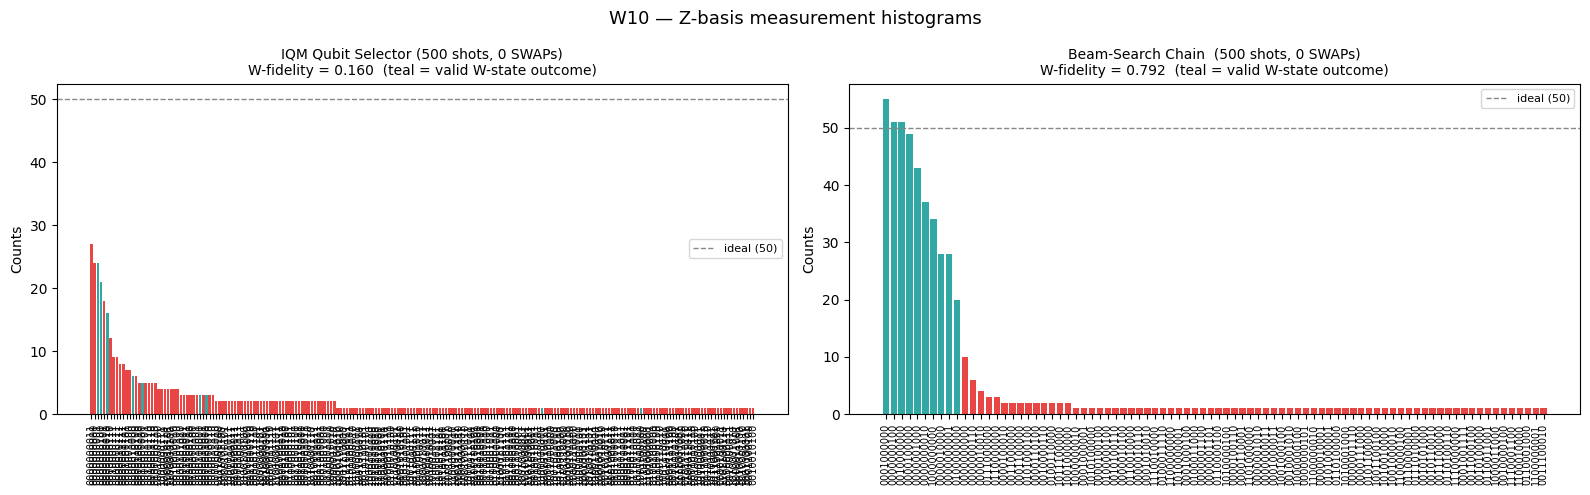

In [30]:
import matplotlib.pyplot as plt

def plot_z_hist(ax, counts, approach_name, shots):
    sorted_counts = sorted(counts.items(), key=lambda x: -x[1])
    labels, vals  = zip(*sorted_counts) if sorted_counts else ([], [])
    colors = ["#32a8a4" if lb in w_bitstrings else "#e84545" for lb in labels]
    ax.bar(range(len(labels)), vals, color=colors)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_ylabel("Counts")
    ax.axhline(shots/N_QUBITS, color="#888", lw=1, ls="--", label=f"ideal ({shots/N_QUBITS:.0f})")
    fid = sum(counts.get(s, 0) for s in w_bitstrings) / shots
    ax.set_title(f"{approach_name}\nW-fidelity = {fid:.3f}  (teal = valid W-state outcome)", fontsize=10)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_z_hist(axes[0], pz_iqm,   f"IQM Qubit Selector ({SHOTS} shots, {iqm_z_swaps} SWAPs)", SHOTS)
plot_z_hist(axes[1], pz_chain, f"Beam-Search Chain  ({SHOTS} shots, {chain_z_swaps} SWAPs)",  SHOTS)
plt.suptitle(f"W{N_QUBITS} — Z-basis measurement histograms", fontsize=13)
plt.tight_layout()
plt.show()

### 9.3 X-basis entanglement witness

For the ideal $|W_N\rangle$: $\langle X_i X_j \rangle = 2/N$ for all $i \neq j$.  
For any classical mixture with the same Z marginals: $\langle X_i X_j \rangle = 0$.  
The average over all pairs is the **entanglement witness** $W$.

In [31]:
def corr_matrix(probs, n):
    C = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            val = sum((1 - 2*int(b[-(i+1)])) * (1 - 2*int(b[-(j+1)])) * p
                      for b, p in probs.items())
            C[i, j] = C[j, i] = val
    return C

ideal_corr  = 2 / N_QUBITS
shot_stderr = 1 / np.sqrt(SHOTS)

C_iqm   = corr_matrix(to_probs(px_iqm),   N_QUBITS)
C_chain = corr_matrix(to_probs(px_chain), N_QUBITS)

upper_iqm   = C_iqm[np.triu_indices(N_QUBITS, k=1)]
upper_chain = C_chain[np.triu_indices(N_QUBITS, k=1)]

W_iqm   = upper_iqm.mean()
W_chain = upper_chain.mean()

print(f"Entanglement witness W = mean ⟨Xi Xj⟩ over {N_QUBITS*(N_QUBITS-1)//2} pairs")
print(f"  Ideal W{N_QUBITS}:         {ideal_corr:.4f}")
print(f"  Classical mixture:    0.0000")
print(f"  Shot noise σ:         ±{shot_stderr:.4f}  (SHOTS={SHOTS})")
print()
print(f"  IQM Selector:         {W_iqm:.4f}  ({W_iqm/ideal_corr*100:.1f}% of ideal, {W_iqm/shot_stderr:.1f}σ)")
print(f"  Chain Routing:        {W_chain:.4f}  ({W_chain/ideal_corr*100:.1f}% of ideal, {W_chain/shot_stderr:.1f}σ)")

Entanglement witness W = mean ⟨Xi Xj⟩ over 45 pairs
  Ideal W10:         0.2000
  Classical mixture:    0.0000
  Shot noise σ:         ±0.0447  (SHOTS=500)

  IQM Selector:         0.0026  (1.3% of ideal, 0.1σ)
  Chain Routing:        0.1616  (80.8% of ideal, 3.6σ)


### 9.4 X-basis correlator heatmaps

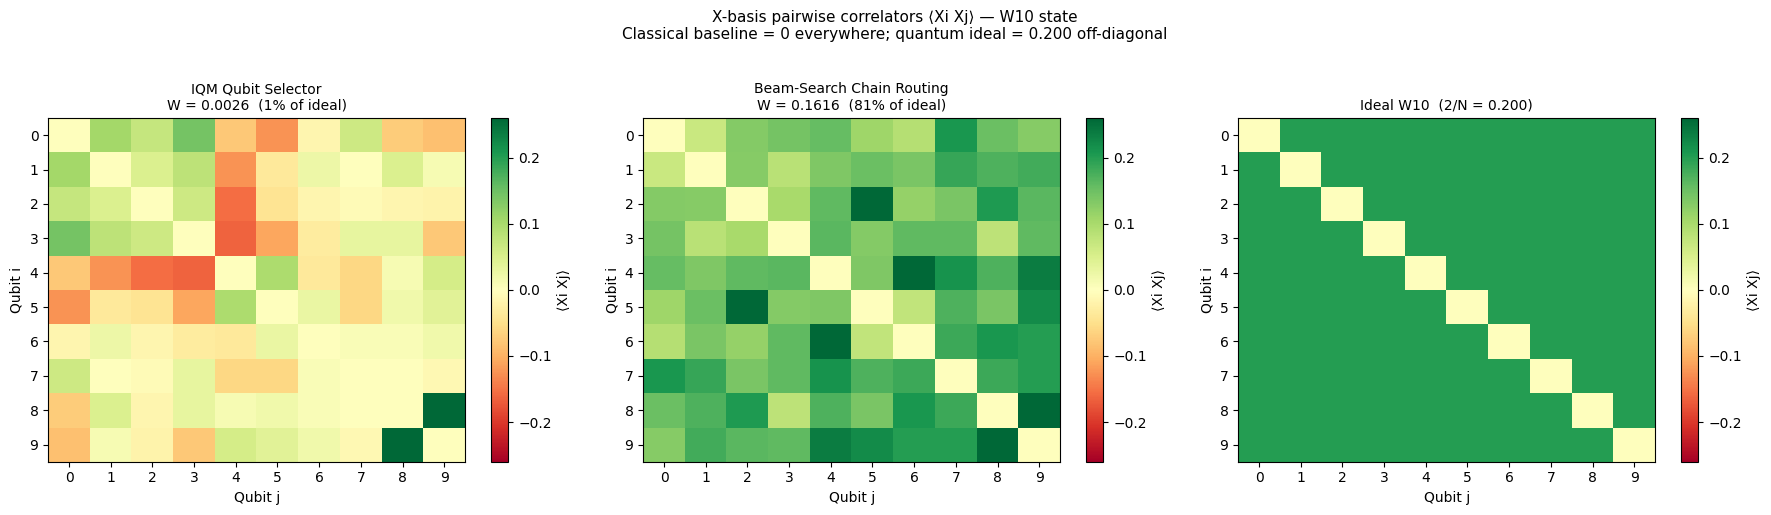

In [32]:
vmax = max(ideal_corr * 1.3, 0.01)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_corr(ax, C, title):
    im = ax.imshow(C, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Qubit j"); ax.set_ylabel("Qubit i")
    ax.set_xticks(range(N_QUBITS)); ax.set_yticks(range(N_QUBITS))
    plt.colorbar(im, ax=ax, label="⟨Xi Xj⟩")

plot_corr(axes[0], C_iqm,
          f"IQM Qubit Selector\nW = {W_iqm:.4f}  ({W_iqm/ideal_corr*100:.0f}% of ideal)")
plot_corr(axes[1], C_chain,
          f"Beam-Search Chain Routing\nW = {W_chain:.4f}  ({W_chain/ideal_corr*100:.0f}% of ideal)")

ideal_M = np.full((N_QUBITS, N_QUBITS), ideal_corr)
np.fill_diagonal(ideal_M, 0)
plot_corr(axes[2], ideal_M, f"Ideal W{N_QUBITS}  (2/N = {ideal_corr:.3f})")

plt.suptitle(
    f"X-basis pairwise correlators ⟨Xi Xj⟩ — W{N_QUBITS} state\n"
    f"Classical baseline = 0 everywhere; quantum ideal = {ideal_corr:.3f} off-diagonal",
    fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

### 9.5 Entanglement witness bar chart

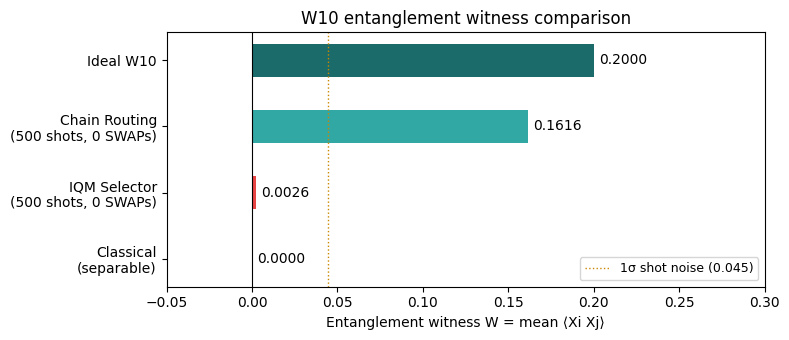

In [33]:
fig, ax = plt.subplots(figsize=(8, 3.5))
categories = ["Classical\n(separable)",
              f"IQM Selector\n({SHOTS} shots, {iqm_z_swaps} SWAPs)",
              f"Chain Routing\n({SHOTS} shots, 0 SWAPs)",
              f"Ideal W{N_QUBITS}"]
values  = [0.0, W_iqm, W_chain, ideal_corr]
colors  = ["#aaaaaa", "#e84545", "#32a8a4", "#1a6b69"]
bars    = ax.barh(categories, values, color=colors, height=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Entanglement witness W = mean ⟨Xi Xj⟩")
ax.set_title(f"W{N_QUBITS} entanglement witness comparison")
ax.set_xlim(-0.05, ideal_corr * 1.5)
for bar, val in zip(bars, values):
    ax.text(max(val + 0.003, 0.003), bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)
ax.axvline(shot_stderr, color="#cc8800", lw=1, ls=":", label=f"1σ shot noise ({shot_stderr:.3f})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 10. Summary

### Results table

In [34]:
print(f"{'Metric':<35} {'IQM Qubit Selector':>20} {'Chain Routing':>15} {'Ideal':>8}")
print("=" * 82)
print(f"{'Qubit selection method':<35} {'CostEvaluator':>20} {'Beam search':>15} {'—':>8}")
print(f"{'Transpilation strategy':<35} {'opt_level=3 (full)':>20} {'routing=none':>15} {'—':>8}")
print(f"{'Z-basis circuit depth':<35} {iqm_z_depth:>20} {chain_z_depth:>15} {'—':>8}")
print(f"{'Z-basis SWAP count':<35} {iqm_z_swaps:>20} {chain_z_swaps:>15} {'0':>8}")
print(f"{'Z-basis W-state fidelity':<35} {fid_iqm:>20.3f} {fid_chain:>15.3f} {'1.000':>8}")
print(f"{'Entanglement witness W':<35} {W_iqm:>20.4f} {W_chain:>15.4f} {ideal_corr:>8.4f}")
print(f"{'W as % of ideal':<35} {W_iqm/ideal_corr*100:>19.1f}% {W_chain/ideal_corr*100:>14.1f}% {'100%':>8}")
print(f"{'W in units of shot noise σ':<35} {W_iqm/shot_stderr:>19.1f}σ {W_chain/shot_stderr:>14.1f}σ {'—':>8}")
print()
print(f"Selected qubits:")
print(f"  IQM Selector  : {iqm_names}")
print(f"  Chain Routing : {chain_names}")
print()
print("Key trade-off:")
print("  IQM Selector  — searches all valid subsets → may pick better qubits, but Qiskit adds SWAPs")
print("  Chain Routing — restricted to hardware paths → guaranteed 0 SWAPs, shallower circuit")
print(f"")
print(f"For the W-state (linear interaction graph), eliminating SWAPs saves ~3 CZ gates per SWAP")
print(f"inserted. At typical CZ fidelity ~0.99, each SWAP costs ~0.97³ ≈ 0.97 in circuit fidelity.")

Metric                                IQM Qubit Selector   Chain Routing    Ideal
Qubit selection method                     CostEvaluator     Beam search        —
Transpilation strategy                opt_level=3 (full)    routing=none        —
Z-basis circuit depth                                 85              23        —
Z-basis SWAP count                                     0               0        0
Z-basis W-state fidelity                           0.160           0.792    1.000
Entanglement witness W                            0.0026          0.1616   0.2000
W as % of ideal                                     1.3%           80.8%     100%
W in units of shot noise σ                          0.1σ            3.6σ        —

Selected qubits:
  IQM Selector  : ['QB1', 'QB34', 'QB33', 'QB5', 'QB6', 'QB10', 'QB11', 'QB12', 'QB18', 'QB26']
  Chain Routing : ['QB12', 'QB11', 'QB5', 'QB1', 'QB2', 'QB6', 'QB7', 'QB13', 'QB14', 'QB22']

Key trade-off:
  IQM Selector  — searches all valid s